# Data imputation techniques
Data processing is one of the most time consuming steps in the ML workflow, sometimes data collection pipelines treats unexpected values and data engineers don't notice to these issues. Also on some scenarios is regard to input errors or the freak is something related with bussines logic.  
So, as part of the preprocessing step before feeding data to our models, we have to decide "What am I going to do with missing data in my dataset?". This notebook tries to explain common techniques to handle this issue and associated advantages. We are going to use synthetic dataset to compare results between techniques.

In [1]:
%pip install miceforest

Note: you may need to restart the kernel to use updated packages.


In [2]:
from pandas import read_csv
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import cross_validate
from sklearn.pipeline import Pipeline
from statistics import geometric_mean
from miceforest import ImputationKernel
from xgboost import XGBClassifier

DATA = read_csv("/kaggle/input/datasets/sridevilavanyacse/student-lifestyle-and-stress-prediction-dataset/student-lifestyle-and-stress-dataset.csv")

CATS = ["Student_Type"]
NUMS = ["Sleep_Hours", "Study_Hours", "Social_Media_Hours", "Attendance", "Exam_Pressure", "Family_Support", "Month"]
TARGET = "Stress_Level"

data = DATA.copy()

def pipeline_training(imputer_cat, imputer_num, drop_data = False, single_imputing = False):
    if (not drop_data) and (not single_imputing):
        data_copy = data
        CAT_PIPELINE = Pipeline([
            ("encoding", OrdinalEncoder()),
            ("impute", imputer_cat)
        ])
        
        NUM_PIPELINE = Pipeline(steps=[
            ("impute", imputer_num),
            ("normalizing", StandardScaler())
        ])
        
        TRANSFORMER = ColumnTransformer([
            ("cat_data", CAT_PIPELINE, CATS),
            ("num_data", NUM_PIPELINE, NUMS),
        ])
    elif (not drop_data) and single_imputing:
        data_copy = data
        ENCODER = OrdinalEncoder()
        ENCODER.set_output(transform="pandas")
        data_copy[CATS] = ENCODER.fit_transform(data_copy[CATS])

        KERNEL_MICE = ImputationKernel(data_copy[CATS + NUMS], random_state=123)

        NUM_PIPELINE = ColumnTransformer([
            ("standarized_num_data", StandardScaler(), NUMS),
            ("pass", "passthrough", CATS)
        ])

        TRANSFORMER = Pipeline(steps=[
            ("impute", KERNEL_MICE),
            ("standarized_data", NUM_PIPELINE)
        ])
    else:
        data_copy = data.dropna()
        print("Instances before dropping: ", len(DATA))
        print("Instances after dropping: ", len(data_copy))

        TRANSFORMER = ColumnTransformer([
            ("normalize", StandardScaler(), NUMS),
            ("encode", OrdinalEncoder(), CATS)
        ])
    
    x, y = data_copy[CATS + NUMS], data_copy[TARGET]

    X = None
    
    if single_imputing:
        X = TRANSFORMER.fit_transform(x, y, impute__iterations=5)
    else:
        X = TRANSFORMER.fit_transform(x)
    
    MODEL = XGBClassifier(random_state=123, learning_rate=5e-2, booster="gbtree", sampling_method="gradient_based")

    CV = cross_validate(MODEL, X, y, scoring=("accuracy", "f1", "recall", "precision"))
    ACCURACY = geometric_mean(CV["test_accuracy"].tolist())
    PRECISION = geometric_mean(CV["test_precision"].tolist())
    RECALL = geometric_mean(CV["test_recall"].tolist())
    F1_SCORE = geometric_mean(CV["test_f1"].tolist())
    
    print("----------------------------")
    print(f"Accuracy: {ACCURACY:0.2f}")
    print(f"Precision: {PRECISION:0.2f}")
    print(f"Recall: {RECALL:0.2f}")
    print(f"F1-Score: {F1_SCORE:0.2f}")

    return { "accuracy": ACCURACY, "precision": PRECISION, "f1-score": F1_SCORE, "recall": RECALL}

## 1. Discard missing data
This a basic strategy that consists on dropping row instances or columns with null values. However, the price is lossing valuable information that could be significant to your model. Also if your dataset is small is possible to your models will suffer overfitting.

In [3]:
METRICS_DROPPED_DATA = pipeline_training(None, None, True)

Instances before dropping:  25500
Instances after dropping:  16809
----------------------------
Accuracy: 0.82
Precision: 0.74
Recall: 0.62
F1-Score: 0.67


## 2. Univariate feature imputation
This category bounds methods ignoring feature relationships, are simple and computationally efficient.

1. **Numerical features:** Calculates the median or mean of the column and imputes missing values with it. Median works fine for skewed and mean is better for normally distributed data.
2. **Categorical features:** Performs a mode calculation for each columns, in case of a column has more than 1 mode, first one is selected.
3. **Other approach:** As the others, consist on manually selecting a constant value to impute in each column.

This technique is recommended for small amounts of missing data (almost 5% of the dataset size) because variable distribution doesn't suffers a lot.

In [4]:
METRICS_UNIVARIATE = pipeline_training(
    SimpleImputer(strategy="most_frequent"),
    SimpleImputer(strategy="mean"),
    False
)

----------------------------
Accuracy: 0.82
Precision: 0.74
Recall: 0.60
F1-Score: 0.66


## 3. Multivariate feature imputation
These approaches are more complex than univariate methods, so it allows to hold feature relationships. Every strategy is based on estimating a feature value from other fields in the dataset.

### KNN imputation
It consists on training a KNN model to estimate feature values from the k-nearest neighbors to data instance. Final estimation is a weighted mean from values of the nearest instances to the imputed row. KNN imputation is fine because holds underlying patterns and relationships among variables but is too slow in big datasets.

In [5]:
METRICS_KNN = pipeline_training(
    SimpleImputer(strategy="most_frequent"),
    KNNImputer(),
    False
)

----------------------------
Accuracy: 0.81
Precision: 0.74
Recall: 0.59
F1-Score: 0.66


### Linear models (logistic and linear regression)
So, this is simple as training a linear (logistic for categorical features) regression model to estimate a feature value. Linear models are simple and relatively quick trainable, but as the name sugests, works well when relationships among variables are linear. On data with quadratic relationship for instance, linear models never will be able to impute values on a good way.  
An additional care must be taken when working with numeric variables because you must be careful if the model estimates a negative value on a positive variable. This approach requires training a linear estimator for eacg variable or a single multioutput model if features with null values has a similar distribution.

### Multiple imputation by chained equations (MICE)
MICE is a very sophisticated but powerful algorithm to address data imputation on multivariate scenarios. It works treating each feature with missing values as a target variable and uses other features to predict those missing values, at the begin assigns an initial value (usually variable mean o median) to make predictions, when an iteration is completed (all variables are imputed once) the process is repeated until reach a stable state. This approach holds relationships among variables at imputed data, suites fine for complex data and works for numerical and categorical data. As you guess, its main trouble comes from his benefits, is a computationally intensive algorithm.

#### Scikit implementation
Scikit library implements MICE on `IterativeImputer` class, by default it uses a `BayesianRidge` model (linear model) to impute data, but we can set our own model to perform model imputation. However, Scikit implementation is experiemental, so has some issues and can change in the future but also works fine.

In [6]:
# Just import this function, don't call it!
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import LogisticRegression, LinearRegression

# In this case we are using linear models
METRICS_MICE = pipeline_training(
    IterativeImputer(
        LogisticRegression(random_state=123), random_state=123
    ),
    IterativeImputer(
        LinearRegression(), random_state=123
    ),
    False
)

----------------------------
Accuracy: 0.82
Precision: 0.74
Recall: 0.60
F1-Score: 0.66


#### `miceforest` implementation
`miforest` is a specialized library for using MICE algorithm in Python, has a stable API for data imputation. It requires that every feature value is a number (for categorical variables must be label encoded). Also supports Scikit pipelines implementing a similar API, so can be integrated easily on your Scikit workflows. Also has support for GPU execution and can be customized in depth.

**Note:** The same data passed to `data` argument at `KernelImputation` constructor must be passed as `x` argument when run `fit()` or `fit_transform` method in a Scikit pipeline.

In [7]:
MICE_LIB_METRICS = pipeline_training(None, None, False, True)

----------------------------
Accuracy: 0.81
Precision: 0.72
Recall: 0.59
F1-Score: 0.65


A manual example is defined here, note that as the other example we are passing the entire dataset without separating target and features and we must run MICE algorithm for one iteration (at least) to impute data.

In [8]:
ENCODER = OrdinalEncoder()
ENCODER.set_output(transform="pandas")
MICE_DATA = data.copy()
MICE_DATA[CATS] = ENCODER.fit_transform(data[CATS])

KERNEL_MICE = ImputationKernel(MICE_DATA, random_state=123)
KERNEL_MICE.mice(5)
mice_data = KERNEL_MICE.complete_data(iteration=5)

SCALER = StandardScaler()
SCALER.set_output(transform="pandas")
mice_data[NUMS] = SCALER.fit_transform(mice_data[NUMS])

X_train, y_train = mice_data[CATS + NUMS], mice_data[TARGET]

MODEL = XGBClassifier(random_state=123, learning_rate=5e-2, booster="gbtree", sampling_method="gradient_based")

CV = cross_validate(MODEL, X_train, y_train, scoring=("accuracy", "f1", "recall", "precision"))
ACCURACY = geometric_mean(CV["test_accuracy"].tolist())
PRECISION = geometric_mean(CV["test_precision"].tolist())
RECALL = geometric_mean(CV["test_recall"].tolist())
F1_SCORE = geometric_mean(CV["test_f1"].tolist())

print("----------------------------")
print(f"Accuracy: {ACCURACY:0.2f}")
print(f"Precision: {PRECISION:0.2f}")
print(f"Recall: {RECALL:0.2f}")
print(f"F1-Score: {F1_SCORE:0.2f}")

MICE_LIB_METRICS = { "accuracy": ACCURACY, "precision": PRECISION, "f1-score": F1_SCORE, "recall": RECALL}

----------------------------
Accuracy: 0.82
Precision: 0.75
Recall: 0.63
F1-Score: 0.68


## Comparison
As metrics printing anticipated, the following chart shows that every imputing techniques had almost the same performance with some downgrades on MICE, KNN and univariate imputation strategies on recall score, compared to dropping data strategy. Other measures had imperceptible changes, but keep in mind that we are using a synthetic dataset, so that explains similar measures.

<Axes: title={'center': 'Comparison between imputing techniques'}>

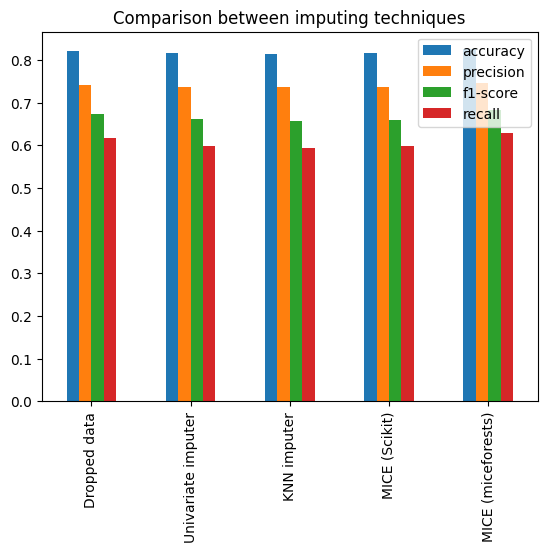

In [9]:
from pandas import DataFrame

plot_data = DataFrame([
   METRICS_DROPPED_DATA, METRICS_UNIVARIATE, METRICS_KNN, METRICS_MICE, MICE_LIB_METRICS 
], index=["Dropped data", "Univariate imputer", "KNN imputer", "MICE (Scikit)", "MICE (miceforests)"])

plot_data.plot.bar(title="Comparison between imputing techniques")